# plotting curves

In [2]:
#!/usr/bin/env python

import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import click


def wrap_family_size_curves(data_sscs):
    '''
    wrap_family_size_curves(data_scss_grouped[["family_size", "in_duplex", "fraction_reads"]])
    '''

    # Pivot the DataFrame
    pivot_df = data_sscs.pivot_table(index='in_duplex', columns='family_size', values='fraction_reads', fill_value=0)

    # If necessary, add columns for family sizes that are not present in the data
    missing_cols = []
    for i in range(1, 202):
        if i not in pivot_df.columns:
            missing_cols.append(i)
    pivot_df[missing_cols] = 0

    # Sort the columns
    pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)

    return pivot_df.reset_index()


def compute_family_sizes_curve(sample, duplex_fam_data, prefix_figure, confidence = '2 1 1', confidence_name = 'low'):
    '''
    this function computes the family size metrics curve
    '''
    confidence_list = [int(x) for x in confidence.split(' ')]
    min_reads = confidence_list[0]
    strand1 = confidence_list[1]
    strand2 = confidence_list[2]

    duplex_fam_data["in_duplex"] = np.logical_and( (duplex_fam_data["ab_size"] + duplex_fam_data["ba_size"]) >= min_reads,
                                                        np.logical_and(duplex_fam_data["ab_size"] >= strand1,
                                                                        duplex_fam_data["ba_size"] >= strand2
                                                                        )
                                                    )

    data_duplex_families_small = duplex_fam_data[["ab_size", "ba_size", "count", "in_duplex"]].copy()

    family_size1 = data_duplex_families_small[["ab_size", "count", "in_duplex"]]
    family_size2 = data_duplex_families_small[["ba_size", "count", "in_duplex"]]
    family_size1.columns = ["family_size", "count", "in_duplex"]
    family_size2.columns = ["family_size", "count", "in_duplex"]

    data_scss = pd.concat((family_size1, family_size2))
    data_scss = data_scss[data_scss["family_size"] > 0].reset_index(drop = True)
    data_scss["count_reads"] = data_scss["family_size"] * data_scss["count"]

    # this way we force that everything above 200 copies gets compressed into 201
    data_scss['family_size'] = data_scss['family_size'].apply(lambda x: x if x <= 200 else 201)
    
    data_scss_grouped = data_scss.groupby(["family_size", "in_duplex"]).sum().reset_index()
    data_scss_grouped["family_size"] = data_scss_grouped["family_size"].astype(int)
    data_scss_grouped["fraction"] = data_scss_grouped["count"] / data_scss_grouped["count"].sum()
    data_scss_grouped["fraction_reads"] = data_scss_grouped["count_reads"] / data_scss_grouped["count_reads"].sum()

    data_family_size_curve = wrap_family_size_curves(data_scss_grouped[["family_size", "in_duplex", "fraction_reads"]])
    orig_cols = list(data_family_size_curve.columns)
    data_family_size_curve["sample"] = sample
    data_family_size_curve["quality"] = confidence_name
    data_family_size_curve = data_family_size_curve[["sample",  "quality"] + orig_cols]


    total_duplex = data_duplex_families_small["count"][data_duplex_families_small["in_duplex"]].sum()
    total_scss = data_scss["count"].sum()
    total_reads = data_scss_grouped["count_reads"].sum()

    total_scss_duplex = data_scss["count"][data_scss["in_duplex"]].sum()
    total_reads_duplex = data_scss_grouped["count_reads"][data_scss["in_duplex"]].sum()
    
    total_scss_nonduplex = data_scss["count"][~data_scss["in_duplex"]].sum()
    total_reads_nonduplex = data_scss_grouped["count_reads"][~data_scss["in_duplex"]].sum()

    percent_duplicates = (1 - total_scss/total_reads) * 100

    expected_dscs = round(total_scss / 2)
    recovery_of_dscs = total_duplex / expected_dscs * 100
    unique_reads = total_duplex + total_scss_nonduplex

    try:
        max_indices = np.argmax( data_scss_grouped[data_scss_grouped['in_duplex']]['fraction_reads'].values )
        peak_size = data_scss_grouped[data_scss_grouped['in_duplex']]['family_size'].values[max_indices]
    except:
        peak_size = 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    sns.lineplot(data=data_scss_grouped,
                 x="family_size",
                 y="fraction_reads",
                 hue="in_duplex",
                 marker='o',
                 palette={True: "k", False: "r"},
                 ax=ax1)

    # Add a vertical bar indicating the peak size
    ax1.axvline(x=peak_size, color="blue", linestyle="--", label=f"Peak:{peak_size}")

    ax1.set_xlim(limx)
    ax1.set_xlabel("Family size")
    ax1.set_ylabel("Fraction of reads")
    ax1.legend(title="in duplex\nfamilies")

    ax2.text(0.15, 0.8, f"Raw reads:   {total_reads:,}\nDuplicates:      {percent_duplicates:.1f}%\n\nSSCs:            {total_scss:,}")
    ax2.text(0.15, 0.6, f"Raw/DSCs:          {total_reads/total_duplex:.3f}\nRaw/SSCs:         {total_reads/total_scss:.3f}\nSSCs/DSCs:    {total_scss/total_duplex:.3f}")
    ax2.text(0.15, 0.25, f"IN DUPLEX\nRaw:                {total_reads_duplex:,} ({total_reads_duplex/(total_reads)*100:.1f}%)\nSSCs:               {total_scss_duplex:,}\nDSCs:            {total_duplex:,}\nRaw/DSCs:         {total_reads_duplex/total_duplex:.3f}\nRaw/SSCs:        {total_reads_duplex/total_scss_duplex:.3f}\n")
    ax2.text(0.15, 0.05, f"NO DUPLEX\nRaw:                {total_reads_nonduplex:,} ({total_reads_nonduplex/(total_reads)*100:.1f}%)\nSSCs:               {total_scss_nonduplex:,} ({total_scss_nonduplex/(total_scss)*100:.1f}%)\nRaw/SSCs:        {total_reads_nonduplex/total_scss_nonduplex:.3f}")
    ax2.axis('off')
    fig.suptitle(f"{sample} Duplex:{confidence_name}({confidence})")
    plt.show()
    fig.savefig(f"{prefix_figure}.{confidence_name}.pdf", bbox_inches='tight')



    keys = ['sample', 'quality', 'quality_threshold', 'raw_reads',
                'duplicates', 'sscs', 'dscs',
                'expected_dscs', 'recovery_of_dscs', 'unique_reads', 'uq_reads_duplex', 'unique_molecules',
                'raw_x_dscs', 'raw_x_sscs', 'sscs_x_dscs',
                'duplex_raw_reads', 'duplex_sscs', 'duplex_raw_x_dscs', 'duplex_raw_x_sscs',
                'noduplex_raw_reads', 'noduplex_sscs', 'noduplex_raw_x_sscs',
                'peak_size']

    values = [sample, confidence_name, confidence, total_reads,
                round(percent_duplicates, 3), total_scss,
                total_duplex,
                expected_dscs, round(recovery_of_dscs, 3), unique_reads, round(total_duplex/unique_reads*100, 3), round(unique_reads/2),
                round(total_reads/total_duplex, 3), round(total_reads/total_scss, 3), round(total_scss/total_duplex, 3),
                total_reads_duplex, total_scss_duplex, round(total_reads_duplex/total_duplex, 3), round(total_reads_duplex/total_scss_duplex, 3),
                total_reads_nonduplex, total_scss_nonduplex, round(total_reads_nonduplex/total_scss_nonduplex, 3),
                peak_size]

    sample_data = pd.DataFrame([values], columns = keys)

    return sample_data, data_family_size_curve



def stats_fam_size2plot(sample, duplex_metrics_file, output_prefix, confidence = '4 2 2'):
    
    # compute family size distributions from duplex stats data
    data_duplex_families = pd.read_table(f"{duplex_metrics_file}")


    sample_data_duplex, data_family_size_curve_duplex = compute_family_sizes_curve(sample, data_duplex_families,
                                                                                    prefix_figure = output_prefix,
                                                                                    confidence = confidence, confidence_name = 'duplex')
    sample_data_low, data_family_size_curve_low = compute_family_sizes_curve(sample, data_duplex_families, 
                                                                                    prefix_figure = output_prefix,
                                                                                    confidence = '2 1 1', confidence_name = 'allm')

    sample_data = pd.concat((sample_data_duplex, sample_data_low), axis = 0)
    sample_data.to_csv(f"{output_prefix}.sample_data.tsv",
                                    sep = "\t",
                                    header = True,
                                    index = False)


    family_size_curve = pd.concat((data_family_size_curve_duplex, data_family_size_curve_low), axis = 0)
    family_size_curve.to_csv(f"{output_prefix}.family_curve.tsv",
                                    sep = "\t",
                                    header = True,
                                    index = False)

    return 0

In [ ]:

# @click.command()
# @click.option('--sample-name', '-n', required=True, type=str, help='Name of the sample.')
# @click.option('--input-file', '-i', required=True, type=click.Path(exists=True), help='Path to the input file.')
# @click.option('--output-file', '-o', required=True, type=click.Path(), help='Path to the output file.')
# @click.option('--confidence-level', '-c', default='4 2 2', show_default=True, type=str, help='Confidence level for the analysis.')
# def main(sample_name, input_file, output_file, confidence_level):
#     """
#     Main function to process the input file and generate plots.
#     """

#     global limx
#     limx = (0,50)

#     stats_fam_size2plot(sample_name, input_file, output_file, confidence=confidence_level)


# if __name__ == '__main__':
#     main()

In [3]:
# SC003_B1_1_H_2

In [6]:
all_data = pd.read_table("curves_summary.all.2025-12-14_idt_tws.tsv")
ontarget_data = pd.read_table("curves_summary.on_target.2025-12-14_idt_tws.tsv")

In [26]:
all_data = all_data[(all_data["sample"] == "SC003_B1_1_H_2")
                    & (all_data["quality"] == "duplex")
                    ]
ontarget_data = ontarget_data[(ontarget_data["sample"] == "SC003_B1_1_H_2")
                    & (ontarget_data["quality"] == "duplex")
                    ]

In [12]:
all_data.head()

,sample,quality,in_duplex,1,2,3,4,5,6,7,...,192,193,194,195,196,197,198,199,200,201
0,SC003_B1_1_H_2,duplex,False,0.0451,0.038013,0.034208,0.029991,0.027135,0.025430,0.024410,...,0,0,0,0,0,0,0,0,0,0
1,SC003_B1_1_H_2,duplex,True,0.0000,0.010250,0.014117,0.017273,0.020028,0.022353,0.024315,...,0,0,0,0,0,0,0,0,0,0


In [20]:
all_data_long = all_data.melt(id_vars=["sample", "quality", "in_duplex"], var_name="family_size", value_name="fraction_reads")
ontarget_data_long = ontarget_data.melt(id_vars=["sample", "quality", "in_duplex"], var_name="family_size", value_name="fraction_reads")
all_data_long["family_size"] = all_data_long["family_size"].astype(int)
ontarget_data_long["family_size"] = ontarget_data_long["family_size"].astype(int)

In [21]:
ontarget_data_long.head()

,sample,quality,in_duplex,family_size,fraction_reads
0,SC003_B1_1_H_2,duplex,False,1,0.025943
1,SC003_B1_1_H_2,duplex,True,1,0.000000
2,SC003_B1_1_H_2,duplex,False,2,0.021080
3,SC003_B1_1_H_2,duplex,True,2,0.010348
4,SC003_B1_1_H_2,duplex,False,3,0.023921


In [38]:
all_data_long["total_reads"] = all_data_long["fraction_reads"] * 120870634
ontarget_data_long["total_reads"] = ontarget_data_long["fraction_reads"] * 88695504

In [39]:
off_target_data_long = all_data_long.merge(ontarget_data_long, on=["sample", "quality", "in_duplex", "family_size"], suffixes=('_all', '_ontarget'))
off_target_data_long["total_reads"] = off_target_data_long["total_reads_all"] - off_target_data_long["total_reads_ontarget"]
off_target_data_long["fraction_reads"] = off_target_data_long["total_reads"] / off_target_data_long["total_reads"].sum()
off_target_data_long.head()

,sample,quality,in_duplex,family_size,fraction_reads_all,total_reads_all,fraction_reads_ontarget,total_reads_ontarget,total_reads,fraction_reads
0,SC003_B1_1_H_2,duplex,False,1,0.045100,5.451229e+06,0.025943,2.300990e+06,3.150240e+06,0.097909
1,SC003_B1_1_H_2,duplex,True,1,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000
2,SC003_B1_1_H_2,duplex,False,2,0.038013,4.594669e+06,0.021080,1.869728e+06,2.724941e+06,0.084691
3,SC003_B1_1_H_2,duplex,True,2,0.010250,1.238885e+06,0.010348,9.178185e+05,3.210663e+05,0.009979
4,SC003_B1_1_H_2,duplex,False,3,0.034208,4.134766e+06,0.023921,2.121644e+06,2.013123e+06,0.062568


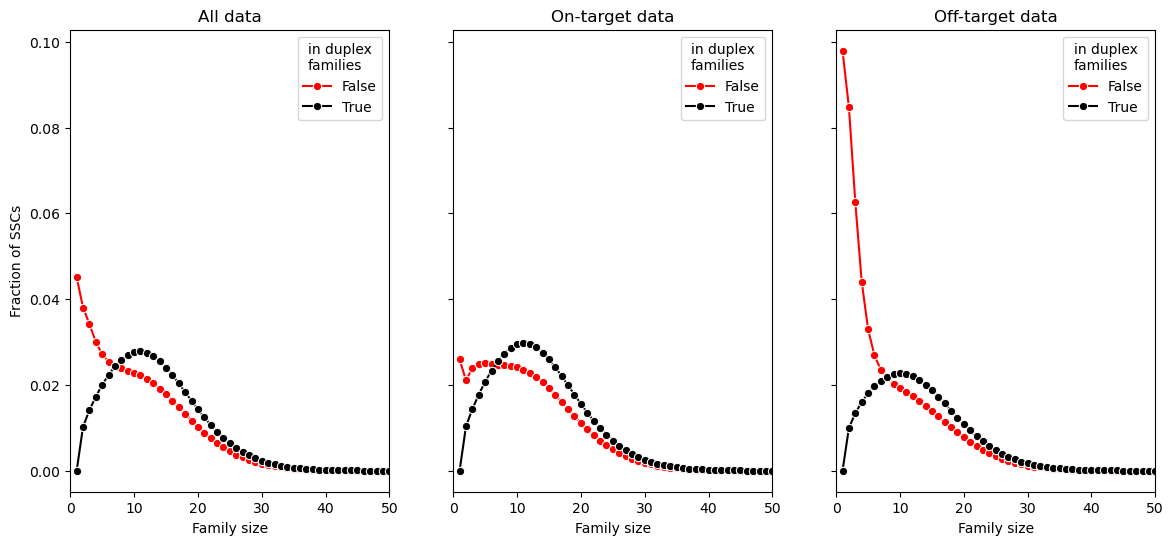

In [40]:
limx = 50
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
sns.lineplot(data=all_data_long,
                x="family_size",
                y="fraction_reads",
                hue="in_duplex",
                marker='o',
                palette={True: "k", False: "r"},
                ax=ax1)
ax1.set_title("All data")
ax1.set_xlim(0, limx)
ax1.set_xlabel("Family size")
ax1.set_ylabel("Fraction of SSCs")
ax1.legend(title="in duplex\nfamilies")

sns.lineplot(data=ontarget_data_long,
                x="family_size",
                y="fraction_reads",
                hue="in_duplex",
                marker='o',
                palette={True: "k", False: "r"},
                ax=ax2)

ax2.set_title("On-target data")
ax2.set_xlim(0, limx)
ax2.set_xlabel("Family size")
# ax2.set_ylabel("Fraction of reads")
ax2.legend(title="in duplex\nfamilies")



sns.lineplot(data=off_target_data_long,
                x="family_size",
                y="fraction_reads",
                hue="in_duplex",
                marker='o',
                palette={True: "k", False: "r"},
                ax=ax3)

ax3.set_title("Off-target data")
ax3.set_xlim(0, limx)
ax3.set_xlabel("Family size")
# ax3.set_ylabel("Fraction of reads")
ax3.legend(title="in duplex\nfamilies")

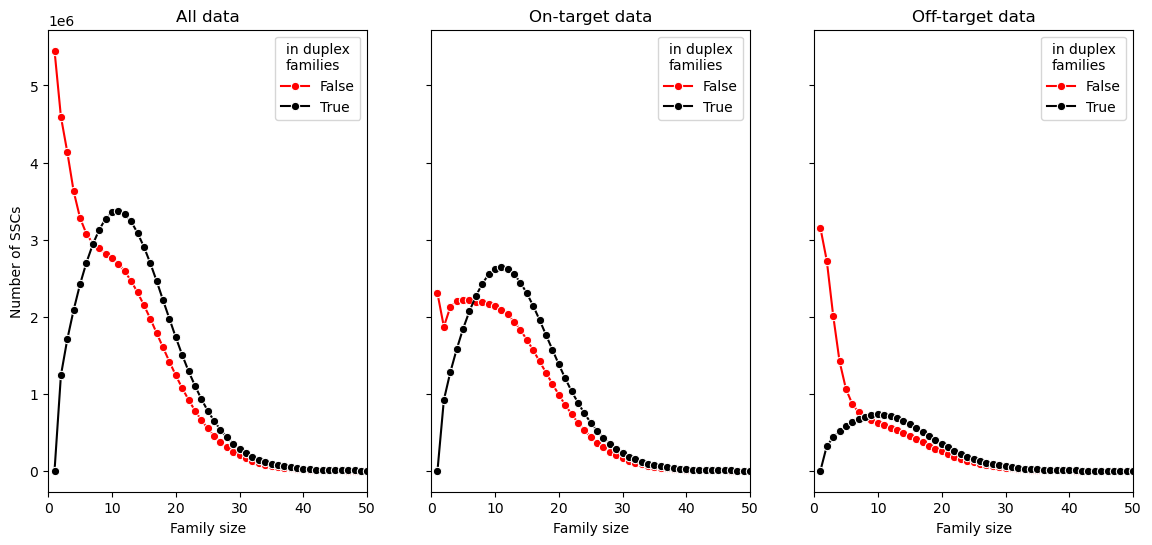

In [41]:

limx = 50
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
sns.lineplot(data=all_data_long,
                x="family_size",
                y="total_reads",
                hue="in_duplex",
                marker='o',
                palette={True: "k", False: "r"},
                ax=ax1)
ax1.set_title("All data")
ax1.set_xlim(0, limx)
ax1.set_xlabel("Family size")
ax1.set_ylabel("Number of SSCs")
ax1.legend(title="in duplex\nfamilies")

sns.lineplot(data=ontarget_data_long,
                x="family_size",
                y="total_reads",
                hue="in_duplex",
                marker='o',
                palette={True: "k", False: "r"},
                ax=ax2)

ax2.set_title("On-target data")
ax2.set_xlim(0, limx)
ax2.set_xlabel("Family size")
# ax2.set_ylabel("Fraction of reads")
ax2.legend(title="in duplex\nfamilies")



sns.lineplot(data=off_target_data_long,
                x="family_size",
                y="total_reads",
                hue="in_duplex",
                marker='o',
                palette={True: "k", False: "r"},
                ax=ax3)

ax3.set_title("Off-target data")
ax3.set_xlim(0, limx)
ax3.set_xlabel("Family size")
# ax3.set_ylabel("Fraction of reads")
ax3.legend(title="in duplex\nfamilies")
